# Vendas de um e-commerce brasileiro: dados reais da Olist

Análise exploratória e de modelagem dos **97 mil pedidos reais** da Olist (2017–2018) usados no
[Insight Engine](../README.md). O notebook mostra as decisões de preparação dos dados e testa, em dados reais,
os métodos que o app usa (segmentação de clientes, previsão e detecção de anomalias) — inclusive onde eles
falham.

**Principais achados**

1. **Entregar no prazo é o que mais pesa na satisfação.** Pedidos atrasados (6,7% dos entregues) têm nota média
   **2,3**, contra **4,3** dos entregues no prazo; 62% deles recebem nota 1 ou 2.
2. **O Nordeste é a região mais mal atendida:** o dobro de atrasos do Sudeste (12,5% contra 6,1%), quase o dobro do
   tempo de entrega e frete 81% mais caro.
3. **Só 3% dos clientes voltam a comprar.** O problema da loja é retenção, não aquisição — e essa característica
   revelou um erro na segmentação RFM do app, corrigido a partir desta análise.
4. **O detector de anomalias encontrou a Black Friday (+505% de pedidos) e a greve dos caminhoneiros de maio de
   2018** sem saber que esses eventos existiram.
5. **Em previsão, a métrica escolhida muda o vencedor:** o Holt-Winters erra menos dia a dia, mas o modelo ingênuo
   erra menos no total do mês.

Fonte: [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce),
licença CC BY-NC-SA 4.0.

In [1]:
# o notebook pode ser aberto da raiz do projeto ou da pasta notebooks/
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "insight_engine").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

In [2]:
import logging

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

from insight_engine.analytics.anomalies import daily_series, detect_anomalies
from insight_engine.analytics.customers import rfm_table, segment_customers
from insight_engine.analytics.forecasting import forecast_revenue
from insight_engine.analytics.kpis import compute_sales_kpis
from insight_engine.data import olist
from insight_engine.formatting import format_brl, format_number, format_pct

logging.disable(logging.WARNING)

# paleta do app (validada para daltonismo) e estilo limpo
BLUE, ORANGE, AQUA, GRAY, RED = "#2a78d6", "#eb6834", "#1baf7a", "#898781", "#e34948"
plt.rcParams.update(
    {
        "figure.figsize": (10, 4),
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e1e0d9",
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,
        "axes.edgecolor": "#c3c2b7",
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "font.size": 10,
    }
)
brl = FuncFormatter(lambda v, _: format_brl(v, 0))
num = FuncFormatter(lambda v, _: format_number(v))
pd.set_option("display.float_format", lambda v: format_number(v, 2))


def date_axis(ax, fmt="%m/%Y"):
    """Datas do eixo no formato brasileiro."""
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def legend(ax, **kwargs):
    ax.legend(frameon=True, facecolor="white", edgecolor="none", framealpha=0.9, **kwargs)

In [3]:
sales = olist.load_olist_sales()  # formato do app: uma linha por pedido e grupo de categoria
orders = olist.load_olist_orders()  # uma linha por pedido: entrega, frete e avaliação
raw_daily = pd.read_csv(olist.RAW_DAILY_FILE, parse_dates=["data"])

kpis = compute_sales_kpis(sales)
print(
    f"Pedidos: {format_number(kpis.n_orders)} | linhas de venda: {format_number(len(sales))} | "
    f"clientes: {format_number(sales['customer_id'].nunique())}"
)
print(f"Receita: {format_brl(kpis.total_revenue)} | ticket médio: {format_brl(kpis.avg_ticket)}")
print(f"Período: {sales['date'].min():%d/%m/%Y} a {sales['date'].max():%d/%m/%Y}")

Pedidos: 97.222 | linhas de venda: 97.754 | clientes: 94.046
Receita: R$ 13.373.379,99 | ticket médio: R$ 137,56
Período: 05/01/2017 a 21/08/2018


## 1. Preparação: as decisões que mudam os resultados

A Olist publica 9 tabelas ligadas por códigos. A preparação (em
[`insight_engine/data/olist.py`](../insight_engine/data/olist.py), gerada por
`scripts/prepare_olist.py`) transforma essas tabelas no formato do app. Quatro decisões merecem explicação.

### 1.1 Janela de datas

A base original vai de setembro de 2016 a outubro de 2018, mas as pontas não representam o negócio:

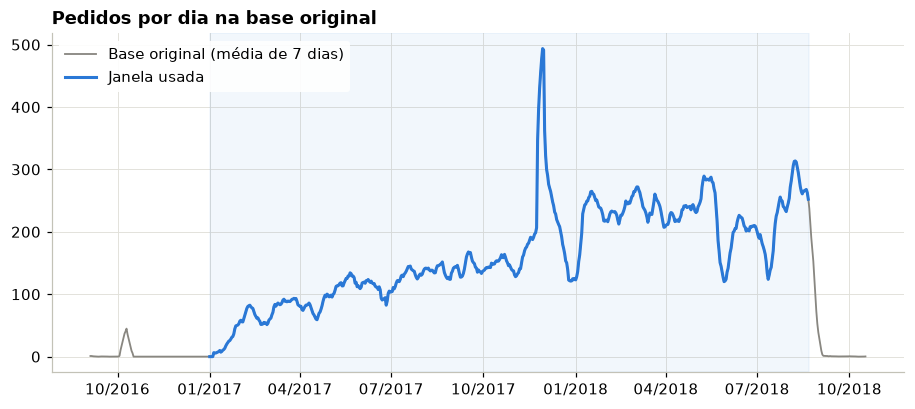

Fim de 2016: 325 pedidos em 3 meses, com um buraco de 2 meses
Últimos dias da coleta: {Timestamp('2018-08-18 00:00:00'): 198, Timestamp('2018-08-19 00:00:00'): 204, Timestamp('2018-08-20 00:00:00'): 256, Timestamp('2018-08-21 00:00:00'): 243, Timestamp('2018-08-22 00:00:00'): 187, Timestamp('2018-08-23 00:00:00'): 144, Timestamp('2018-08-24 00:00:00'): 99, Timestamp('2018-08-25 00:00:00'): 69, Timestamp('2018-08-26 00:00:00'): 73, Timestamp('2018-08-27 00:00:00'): 67, Timestamp('2018-08-28 00:00:00'): 44, Timestamp('2018-08-29 00:00:00'): 14, Timestamp('2018-08-30 00:00:00'): 4, Timestamp('2018-08-31 00:00:00'): 1, Timestamp('2018-09-01 00:00:00'): 0, Timestamp('2018-09-02 00:00:00'): 0, Timestamp('2018-09-03 00:00:00'): 4}


In [4]:
window = (raw_daily["data"] >= olist.START) & (raw_daily["data"] <= olist.END)
fig, ax = plt.subplots()
ax.plot(
    raw_daily["data"],
    raw_daily["pedidos"].rolling(7, min_periods=1).mean(),
    color=GRAY,
    lw=1.2,
    label="Base original (média de 7 dias)",
)
ax.plot(
    raw_daily.loc[window, "data"],
    raw_daily.loc[window, "pedidos"].rolling(7, min_periods=1).mean(),
    color=BLUE,
    lw=2,
    label="Janela usada",
)
ax.axvspan(olist.START, olist.END, color=BLUE, alpha=0.06)
ax.set_title("Pedidos por dia na base original")
ax.yaxis.set_major_formatter(num)
date_axis(ax)
legend(ax, loc="upper left")
plt.show()

edges = raw_daily.set_index("data")["pedidos"]
print("Fim de 2016:", edges["2016-10-01":"2016-12-31"].sum(), "pedidos em 3 meses, com um buraco de 2 meses")
print("Últimos dias da coleta:", edges["2018-08-18":"2018-09-03"].to_dict())

- **Antes de 2017** há só ~330 pedidos e um buraco de dois meses: é a fase de teste da plataforma.
- **A partir de 22/08/2018** os pedidos caem de ~250 para quase zero em dez dias. Não é uma queda nas vendas: é o
  fim da coleta (pedidos recentes ainda não tinham entrado na base). Manter esse trecho faria qualquer modelo
  de previsão "aprender" um colapso que não aconteceu.

Janela usada: **01/01/2017 a 21/08/2018**. Pedidos cancelados ou indisponíveis (1,2%) também ficam de fora.

### 1.2 Cliente único

A tabela de pedidos traz um `customer_id` que **muda a cada pedido**; o cliente de verdade é o
`customer_unique_id`. Usar o primeiro faria a taxa de recompra ser exatamente 0%:

In [5]:
per_customer = orders.groupby("customer")["purchased_at"].count()
print(f"Pedidos: {format_number(len(orders))} | clientes únicos: {format_number(per_customer.size)}")
print(
    f"Clientes com mais de um pedido: {format_pct((per_customer > 1).mean() * 100)} "
    f"(com o customer_id da tabela de pedidos seria 0%)"
)

Pedidos: 97.222 | clientes únicos: 94.046
Clientes com mais de um pedido: 3,0% (com o customer_id da tabela de pedidos seria 0%)


### 1.3 Categorias e linhas por pedido

As 73 categorias originais viram **14 grupos** (gráficos e filtros legíveis); a categoria original vira o
"produto", porque os produtos da Olist são só códigos. Cada linha da tabela de vendas é um pedido **e** um grupo:
só 0,5% dos pedidos misturam grupos, e o código do pedido é mantido para que "pedidos" e "frequência de compra"
contem pedidos, e não linhas.

### 1.4 O que a base não tem

A Olist **não informa custo**. Lucro e margem ficam indisponíveis no app — em vez de estimados com uma margem
inventada. Receita, aqui, é o valor dos itens: o frete não é receita do vendedor.

## 2. Como a loja vende

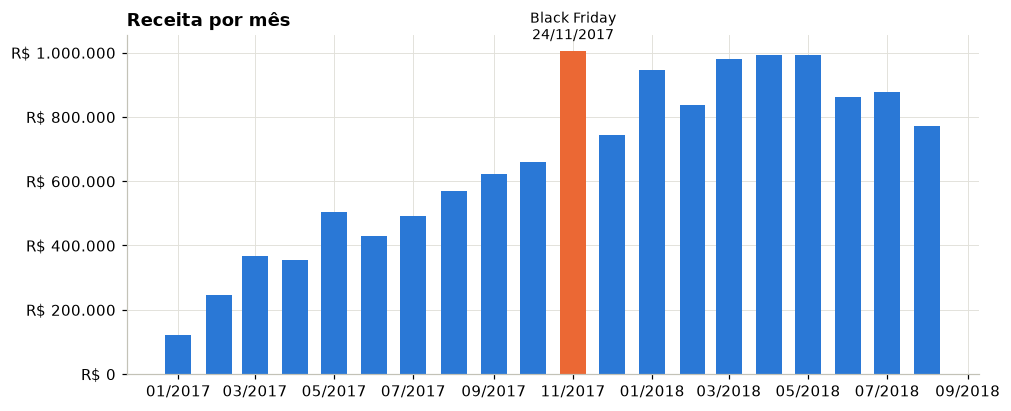

Receita média mensal jan–jul/2018 vs jan–jul/2017: +158,4%


In [6]:
monthly = sales.set_index("date")["revenue"].resample("MS").sum()
fig, ax = plt.subplots()
ax.bar(monthly.index, monthly.values, width=20, color=BLUE)
bf = monthly.index.get_loc(pd.Timestamp("2017-11-01"))
ax.bar(monthly.index[bf], monthly.values[bf], width=20, color=ORANGE)
ax.annotate(
    "Black Friday\n24/11/2017",
    (monthly.index[bf], monthly.values[bf]),
    xytext=(0, 8),
    textcoords="offset points",
    ha="center",
    fontsize=9,
)
ax.set_title("Receita por mês")
ax.yaxis.set_major_formatter(brl)
date_axis(ax)
plt.show()

growth = monthly["2018-01":"2018-07"].mean() / monthly["2017-01":"2017-07"].mean() - 1
print(f"Receita média mensal jan–jul/2018 vs jan–jul/2017: {format_pct(growth * 100, signed=True)}")

A loja **cresceu rápido em 2017** e estabilizou em 2018 (perto de R$ 0,9–1 milhão por mês). Novembro de 2017 é o
maior mês, puxado por um único dia: a Black Friday.

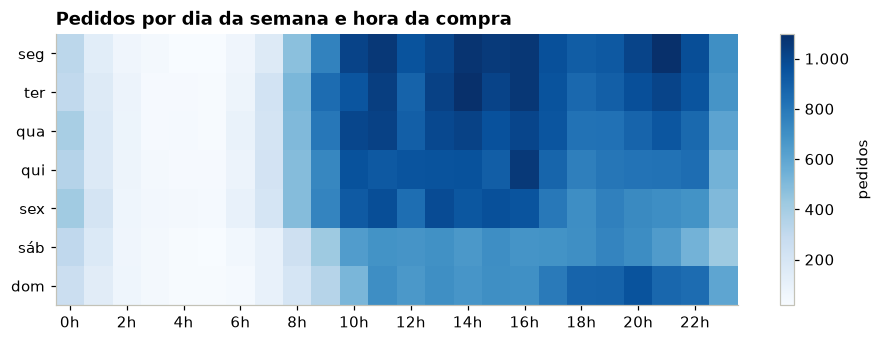

In [7]:
when = sales.assign(dia=sales["date"].dt.dayofweek, hora=sales["date"].dt.hour)
grid = when.pivot_table(index="dia", columns="hora", values="order_id", aggfunc="nunique", fill_value=0)
fig, ax = plt.subplots(figsize=(10, 3.2))
image = ax.imshow(grid, aspect="auto", cmap="Blues")
ax.set_yticks(range(7), ["seg", "ter", "qua", "qui", "sex", "sáb", "dom"])
ax.set_xticks(range(0, 24, 2), [f"{h}h" for h in range(0, 24, 2)])
ax.grid(False)
ax.set_title("Pedidos por dia da semana e hora da compra")
fig.colorbar(image, ax=ax, label="pedidos", format=num)
plt.show()

As compras se concentram **de segunda a quinta, das 10h às 22h**; um dia de fim de semana vende cerca de 25%
menos que um dia útil. Para uma
loja online, é um sinal de que boa parte das compras acontece durante a semana de trabalho — útil para decidir
quando rodar campanhas e quando reforçar o atendimento.

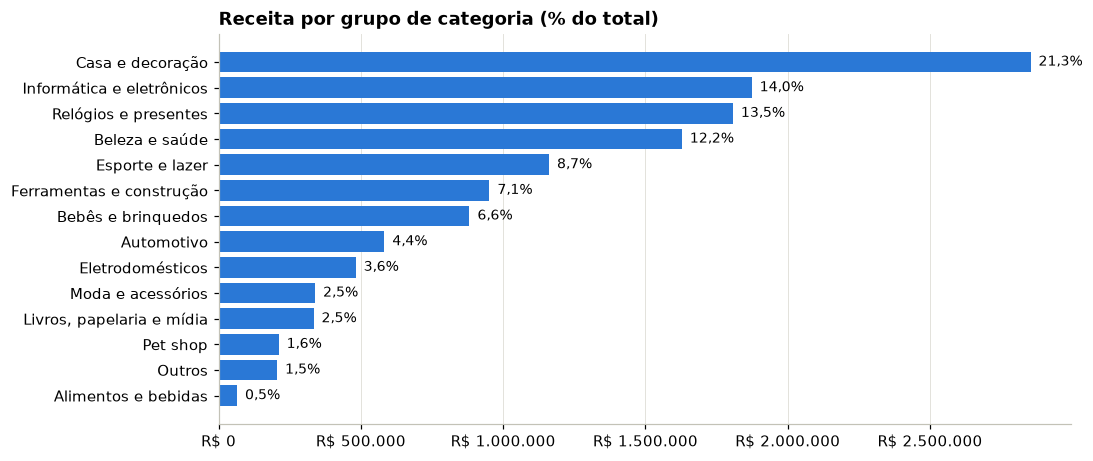

In [8]:
by_group = sales.groupby("category")["revenue"].sum().sort_values()
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.barh(by_group.index, by_group.values, color=BLUE)
for y, value in enumerate(by_group.values):
    ax.text(value, y, f"  {format_pct(value / by_group.sum() * 100)}", va="center", fontsize=9)
ax.set_title("Receita por grupo de categoria (% do total)")
ax.xaxis.set_major_formatter(brl)
ax.grid(axis="y", visible=False)
plt.show()

## 3. Entrega e satisfação

A tabela de pedidos traz a data de entrega, o prazo prometido e a nota da avaliação (1 a 5). Atraso = dias entre
o prazo prometido e a entrega.

In [9]:
delivered = orders[(orders["status"] == "delivered") & orders["delivered_at"].notna() & orders["review_score"].notna()]
delivered = delivered.assign(
    atraso=(delivered["delivered_at"] - delivered["estimated_at"]).dt.days,
    dias=(delivered["delivered_at"] - delivered["purchased_at"]).dt.days,
)
delivered["atrasado"] = delivered["atraso"] > 0

summary = (
    delivered.groupby("atrasado")
    .agg(
        pedidos=("review_score", "size"),
        nota_media=("review_score", "mean"),
        notas_ruins=("review_score", lambda s: (s <= 2).mean() * 100),
    )
    .rename(index={False: "No prazo", True: "Atrasado"})
)
print(f"Pedidos entregues com atraso: {format_pct(delivered['atrasado'].mean() * 100)}")
summary

Pedidos entregues com atraso: 6,7%


,pedidos,nota_media,notas_ruins
atrasado,,,
No prazo,88507,"4,29","9,22"
Atrasado,6373,"2,27","62,37"


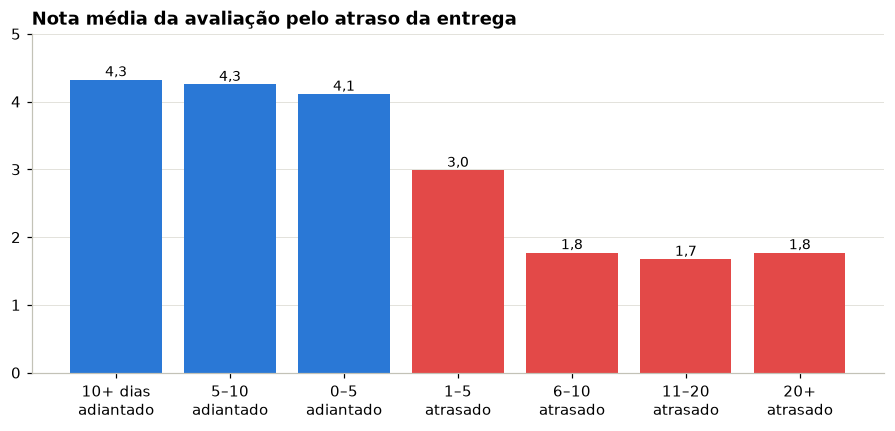

In [10]:
bins = [-1000, -10, -5, 0, 5, 10, 20, 1000]
labels = [
    "10+ dias\nadiantado",
    "5–10\nadiantado",
    "0–5\nadiantado",
    "1–5\natrasado",
    "6–10\natrasado",
    "11–20\natrasado",
    "20+\natrasado",
]
curve = delivered.groupby(pd.cut(delivered["atraso"], bins, labels=labels), observed=True)["review_score"].mean()

fig, ax = plt.subplots()
colors = [BLUE if i < 3 else RED for i in range(len(curve))]
ax.bar(curve.index.astype(str), curve.values, color=colors)
for x, value in enumerate(curve.values):
    ax.text(x, value + 0.05, format_number(value, 1), ha="center", fontsize=9)
ax.set_ylim(0, 5)
ax.set_title("Nota média da avaliação pelo atraso da entrega")
ax.grid(axis="x", visible=False)
plt.show()

O efeito é um **degrau, não uma rampa**: entregar antes do prazo quase não muda a nota (4,1 a 4,3), mas
**qualquer atraso derruba a nota para perto de 3 — e, passando de 5 dias, para menos de 2**. Para o negócio, o
prazo prometido funciona como um contrato: prometer prazos mais folgados (e cumpri-los) vale mais que entregar
rápido.

In [11]:
regions = (
    delivered.groupby("region", observed=True)
    .agg(
        pedidos=("review_score", "size"),
        atrasados_pct=("atrasado", lambda s: s.mean() * 100),
        dias_ate_entrega=("dias", "mean"),
        frete_medio=("freight", "mean"),
        nota_media=("review_score", "mean"),
    )
    .sort_values("atrasados_pct", ascending=False)
)
regions

,pedidos,atrasados_pct,dias_ate_entrega,frete_medio,nota_media
region,,,,,
Nordeste,8940,"12,53","19,45","35,97","3,97"
Norte,1774,"8,34","22,06","41,28","4,03"
Centro-Oeste,5564,"6,49","14,55","26,42","4,13"
Sudeste,64957,"6,07","10,29","19,85","4,18"
Sul,13645,"5,86","13,54","24,34","4,19"


O **Nordeste** tem o dobro de atrasos do Sudeste, quase o dobro do tempo de entrega e frete bem mais caro — e a
pior nota. O Norte espera ainda mais, mas atrasa menos: lá os prazos prometidos já são longos. É exatamente o
efeito do gráfico anterior: o que pune a nota é **descumprir** o prazo, não o prazo longo.

## 4. Clientes: quase ninguém volta

In [12]:
rfm = rfm_table(sales)
print(f"Clientes que compraram mais de uma vez: {format_pct((rfm['frequency'] > 1).mean() * 100)}")
print(rfm["frequency"].value_counts().head(4).rename("clientes").to_string())

Clientes que compraram mais de uma vez: 3,0%
frequency
1    91194
2     2619
3      186
4       28


**97% dos clientes compraram uma única vez.** Isso quebrou um detalhe do método RFM do app. Cada dimensão vira
uma nota de 1 a 5 por quintis; a versão anterior desempatava valores iguais pela ordem das linhas
(`rank(method="first")`). Na base sintética, onde quase todos compram várias vezes, isso não aparecia. Aqui, com
90 mil clientes empatados em "1 compra", clientes idênticos recebiam notas de 1 a 5 ao acaso:

In [13]:
def old_frequency_score(freq):
    """Método anterior: desempata pela ordem das linhas."""
    return pd.qcut(freq.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)


one_purchase = rfm["frequency"] == 1
old_f = old_frequency_score(rfm["frequency"])
old_r = pd.qcut(rfm["recency"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
print("Nota de frequência de quem comprou UMA vez, método anterior:")
print(old_f[one_purchase].value_counts().sort_index().rename("clientes").to_string())
old_champions = (old_r >= 4) & (old_f >= 4)  # regra dos Campeões
print(
    f"\nCampeões no método anterior: {format_number(old_champions.sum())}, "
    f"dos quais compraram uma vez só: {format_number((old_champions & one_purchase).sum())}"
)

segmentation = segment_customers(sales)  # método atual: empates recebem a mesma nota
champions = segmentation.customers[segmentation.customers["segment"] == "Campeões"]
print(
    f"\nCampeões no método atual: {format_number(len(champions))}, "
    f"dos quais compraram uma vez só: {(champions['frequency'] == 1).sum()}"
)

Nota de frequência de quem comprou UMA vez, método anterior:
frequency
1    18810
2    18809
3    18809
4    18809
5    15957

Campeões no método anterior: 15.030, dos quais compraram uma vez só: 13.809



Campeões no método atual: 1.214, dos quais compraram uma vez só: 0


No método anterior, **92% dos "Campeões" (13.809 de 15.030) tinham comprado uma única vez**. A correção dá a mesma nota a
valores iguais (`rank(method="min", pct=True)`): todos os clientes de uma compra ficam com frequência 1, e os
Campeões passam a ser só quem voltou a comprar. Um bug que só dados reais mostrariam.

In [14]:
segmentation.segments[["customers", "customers_pct", "revenue_pct", "avg_recency"]].rename(
    columns={
        "customers": "clientes",
        "customers_pct": "% clientes",
        "revenue_pct": "% receita",
        "avg_recency": "dias desde a última compra",
    }
)

,clientes,% clientes,% receita,dias desde a última compra
segment,,,,
Campeões,1214,"1,29","2,46","83,70"
Clientes fiéis,603,"0,64","1,16","210,18"
Novos clientes,36203,"38,49","38,23","85,22"
Precisam de atenção,18090,"19,24","17,62","212,90"
Em risco,1035,"1,10","1,94","373,82"
Hibernando,18534,"19,71","19,59","308,55"
Perdidos,18367,"19,53","19,01","463,67"


In [15]:
# grupos do K-Means (k escolhido pela silhueta), com o segmento RFM predominante em cada um
print(f"k escolhido: {segmentation.best_k}")
segmentation.clusters

k escolhido: 3


,customers,avg_recency,avg_frequency,avg_monetary,revenue,revenue_pct,main_segment,main_segment_pct
Grupo 1,2852,"215,72","2,11","260,48","742.889,68","5,55",Campeões,"42,57"
Grupo 2,17893,"40,18","1,00","140,50","2.513.900,69","18,80",Novos clientes,"100,00"
Grupo 3,73301,"279,02","1,00","138,01","10.116.589,62","75,65",Hibernando,"25,28"


O maior grupo é **"Novos clientes"** (compraram uma vez, recentemente): a base de onde sairiam os clientes fiéis,
se houvesse um esforço de segunda compra. Somando "Hibernando" e "Perdidos", ~39% dos clientes não compram há
muito tempo (em média 10 e 15 meses) e dificilmente voltam. O K-Means, sem regra nenhuma, chega à mesma divisão
(recompra × compra única recente × compra única antiga), o que reforça os segmentos.

## 5. Previsão de receita: a métrica escolhe o vencedor

O app compara três modelos em backtesting: cada um é treinado só com o passado e testado em janelas de 30 dias
que não viu.

In [16]:
revenue = daily_series(sales, "revenue")
result = forecast_revenue(revenue, horizon=30)
result.scores.rename(
    columns={
        "wape": "WAPE diário (%)",
        "total_error": "erro do total em 30 dias (%)",
        "bias": "viés (%)",
        "rmse": "RMSE (R$)",
        "improvement_vs_baseline": "ganho vs baseline (%)",
    }
)

,WAPE diário (%),RMSE (R$),viés (%),erro do total em 30 dias (%),ganho vs baseline (%)
Holt-Winters,"20,49","8.114,33","9,80","11,70","10,59"
Ingênuo sazonal (baseline),"22,92","8.852,27","5,75","8,21","0,00"
Regressão com calendário,"25,91","9.841,42","-14,01","19,10","-13,06"


O **Holt-Winters vence pelo critério do app (menor erro diário)**, mas o **modelo ingênuo**, que só repete a
última semana, erra **menos no total dos 30 dias** (8,2% contra 11,7%). Os dois critérios respondem perguntas
diferentes: "quanto vou vender em cada dia?" (logística, equipe) e "quanto vou vender no mês?" (meta, caixa).
Para a meta mensal, o modelo mais simples seria a escolha certa.

A **regressão com calendário**, que vence na base sintética, é a pior aqui: o crescimento de 2017 não é uma reta,
e a Black Friday distorce a tendência. Dados reais punem modelos que assumem um formato para o crescimento.

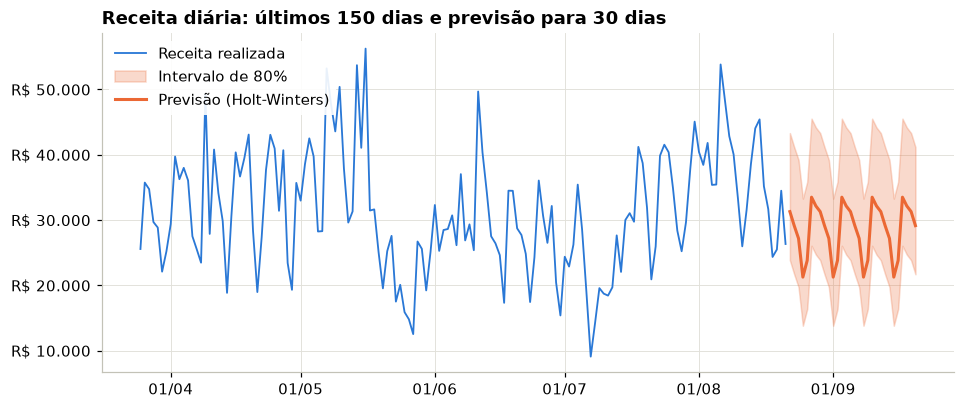

Receita prevista para 30 dias: R$ 853.523,04 (erro típico do total: ± 11,7%)


In [17]:
history = result.history.iloc[-150:]
fc = result.forecast
fig, ax = plt.subplots()
ax.plot(history.index, history.values, color=BLUE, lw=1.2, label="Receita realizada")
ax.fill_between(fc.index, fc["lower_80"], fc["upper_80"], color=ORANGE, alpha=0.25, label="Intervalo de 80%")
ax.plot(fc.index, fc["yhat"], color=ORANGE, lw=2, label=f"Previsão ({result.best_model})")
ax.set_title("Receita diária: últimos 150 dias e previsão para 30 dias")
ax.yaxis.set_major_formatter(brl)
date_axis(ax, "%d/%m")
legend(ax, loc="upper left")
plt.show()
print(
    f"Receita prevista para 30 dias: {format_brl(fc['yhat'].sum())} (erro típico do total: ± "
    f"{format_pct(result.total_error_pct)})"
)

## 6. Anomalias: o detector encontrou eventos reais

O detector do app decompõe a série de pedidos por dia (tendência + padrão semanal, em escala logarítmica) e
marca os dias cujo resíduo foge do padrão (z-score robusto acima de 3,5 e desvio de pelo menos 20%). Ele não
sabe nada sobre datas especiais.

34 dias marcados em 594:
Início da operação         14
Greve dos caminhoneiros     7
outros                      5
Natal e Ano-Novo            5
Black Friday                3


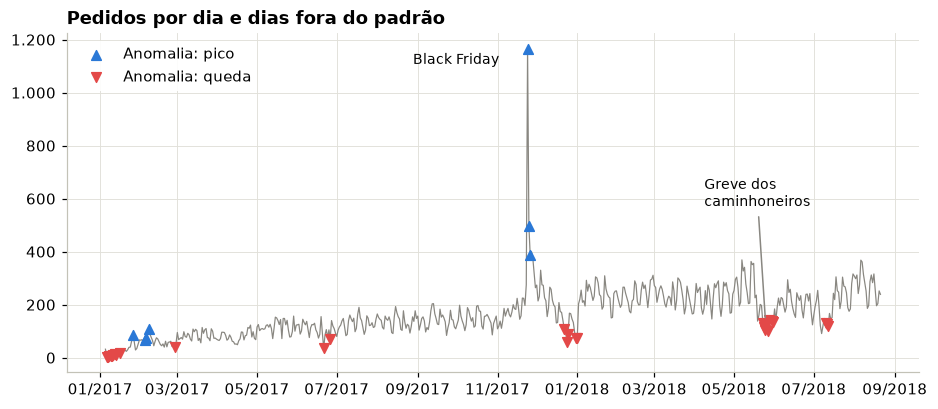

In [18]:
daily_orders = daily_series(sales, "orders")
found = detect_anomalies(daily_orders)
events = {
    "Black Friday": ("2017-11-24", "2017-11-26"),
    "Greve dos caminhoneiros": ("2018-05-21", "2018-05-31"),
    "Natal e Ano-Novo": ("2017-12-22", "2018-01-01"),
    "Início da operação": ("2017-01-01", "2017-02-28"),
}
labeled = pd.Series("outros", index=found.index)
for name, (start, end) in events.items():
    labeled[(found.index >= start) & (found.index <= end)] = name
print(f"{len(found)} dias marcados em {format_number(len(daily_orders))}:")
print(labeled.value_counts().to_string())

fig, ax = plt.subplots()
ax.plot(daily_orders.index, daily_orders.values, color=GRAY, lw=0.8)
for kind, color, marker in (("pico", BLUE, "^"), ("queda", RED, "v")):
    points = found[found["kind"] == kind]
    ax.scatter(points.index, points["value"], color=color, marker=marker, s=40, zorder=3, label=f"Anomalia: {kind}")
ax.annotate(
    "Black Friday", (pd.Timestamp("2017-11-24"), 1166), xytext=(-75, -10), textcoords="offset points", fontsize=9
)
ax.annotate(
    "Greve dos\ncaminhoneiros",
    (pd.Timestamp("2018-05-25"), 140),
    xytext=(-40, 75),
    textcoords="offset points",
    fontsize=9,
    arrowprops=dict(arrowstyle="-", color=GRAY),
)
ax.set_title("Pedidos por dia e dias fora do padrão")
ax.yaxis.set_major_formatter(num)
date_axis(ax)
legend(ax, loc="upper left")
plt.show()

In [19]:
# os dias marcados nos dois eventos reais, com o valor esperado pelo padrão
table = found.assign(evento=labeled).query("evento in ['Black Friday', 'Greve dos caminhoneiros']").sort_index()
table[["evento", "kind", "value", "expected", "deviation_pct"]].rename(
    columns={
        "kind": "tipo",
        "value": "pedidos",
        "expected": "esperado",
        "deviation_pct": "desvio (%)",
    }
)

,evento,tipo,pedidos,esperado,desvio (%)
2017-11-24,Black Friday,pico,"1.166,00","192,74","504,97"
2017-11-25,Black Friday,pico,"498,00","154,72","221,88"
2017-11-26,Black Friday,pico,"387,00","180,73","114,13"
2018-05-23,Greve dos caminhoneiros,queda,"132,00","269,27","-50,98"
2018-05-24,Greve dos caminhoneiros,queda,"114,00","248,87","-54,19"
2018-05-25,Greve dos caminhoneiros,queda,"103,00","206,94","-50,23"
2018-05-27,Greve dos caminhoneiros,queda,"100,00","184,32","-45,75"
2018-05-28,Greve dos caminhoneiros,queda,"142,00","256,30","-44,60"
2018-05-30,Greve dos caminhoneiros,queda,"140,00","257,95","-45,73"
2018-05-31,Greve dos caminhoneiros,queda,"133,00","237,70","-44,05"


- A **Black Friday** de 2017 aparece com +505% de pedidos (3 dias marcados, de sexta a domingo).
- A **greve dos caminhoneiros** (21 a 31 de maio de 2018), que parou o transporte de cargas no país, aparece como
  uma sequência de quedas de 44% a 54% — o detector achou um evento real que não estava em nenhum dado.
- **Natal e Ano-Novo** aparecem como quedas: são datas atípicas, mas previsíveis. O detector só modela o padrão
  semanal, então feriados viram alertas.
- **Janeiro e fevereiro de 2017** concentram alertas porque a operação estava começando (poucos pedidos por dia,
  muita variação relativa).

Na base sintética o detector acertou as 3 anomalias plantadas com poucos alarmes falsos. Em dados reais ele
continua encontrando o que importa, mas precisaria de um **calendário de feriados** e de um período mínimo de
estabilidade para cortar os alertas previsíveis — é a próxima melhoria natural.

## 7. Conclusões e limitações

**Para o negócio**
- A alavanca de satisfação é **cumprir o prazo prometido**; o Nordeste é onde isso mais falha.
- Com 97% de compra única, **a segunda compra é a maior oportunidade**: campanhas para "Novos clientes" nos
  primeiros 30 dias após a compra.
- Black Friday e datas sazonais concentram demanda; a greve de 2018 mostra a dependência da logística rodoviária.

**Para os métodos do app**
- Dados reais revelaram um **erro na segmentação RFM** (empates), corrigido no app.
- Em previsão, **o critério de escolha do modelo deve seguir a decisão** que a previsão apoia (dia a dia ou total).
- A detecção de anomalias precisa de **feriados** para separar o atípico do inesperado.

**Limitações**
- Sem custo, não há análise de lucro.
- A avaliação mede a experiência do pedido inteiro (produto, vendedor, entrega); o atraso explica muito, mas não
  tudo.
- A base é de 2017–2018 e de um único marketplace: os padrões não se transferem automaticamente para outras lojas.